WARNING    Removing unsupported flag '-march=native' from compiler flags. [brian2.codegen.cpp_prefs]


Running network... this may take a minute!
Starting simulation at t=0. s for a duration of 2. s
2. s (100%) simulated in 1s
Done! Plotting results...


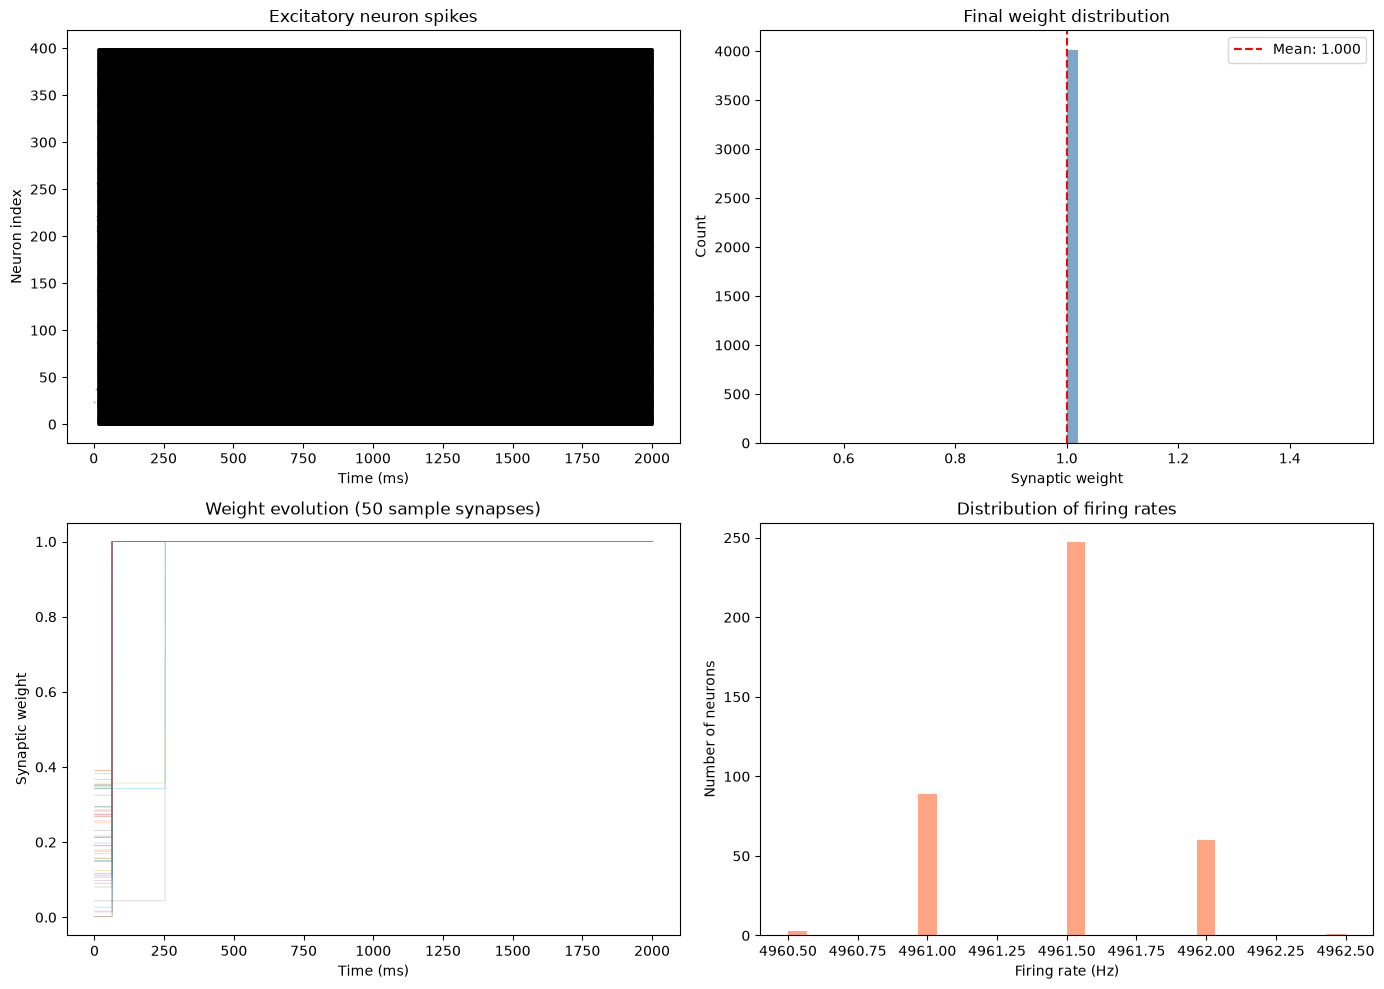


Network statistics:
Total spikes: 3969167
Mean firing rate: 4961.46 Hz
Mean synaptic weight: 1.0000
Synapses near zero (<0.05): 0
Strong synapses (>0.5): 4011


In [1]:
from brian2 import *
import numpy as np
import matplotlib.pyplot as plt

start_scope()

# Network parameters
n_input = 100      # input neurons (sensory layer)
n_excit = 400      # excitatory neurons (memory layer)

# Time constants
tau_mem = 20*ms    # membrane time constant
tau_pre = 20*ms    # STDP pre-synaptic trace
tau_post = 20*ms   # STDP post-synaptic trace

# Neuron equations
eqs = '''
dv/dt = -v/tau_mem : 1
'''

# Create neuron groups
input_layer = PoissonGroup(n_input, rates=10*Hz)  # random firing input
excit_layer = NeuronGroup(n_excit, eqs,
                          threshold='v>0.8',
                          reset='v=0',
                          method='exact')

# STDP synapse equations
stdp_eqs = '''
w : 1
dapre/dt = -apre/tau_pre : 1 (event-driven)
dapost/dt = -apost/tau_post : 1 (event-driven)
'''

on_pre = '''
v_post += w
apre += 0.01
w = clip(w + apost, 0, 1)
'''

on_post = '''
apost += 0.01
w = clip(w + apre, 0, 1)
'''

# Connect input to excitatory layer with STDP
S_input = Synapses(input_layer, excit_layer,
                   stdp_eqs,
                   on_pre=on_pre,
                   on_post=on_post)
S_input.connect(p=0.1)
S_input.w = 'rand() * 0.4'

# Also connect excitatory neurons to each other
S_recurrent = Synapses(excit_layer, excit_layer,
                       stdp_eqs,
                       on_pre=on_pre,
                       on_post=on_post)
S_recurrent.connect(p=0.05, condition='i!=j')
S_recurrent.w = 'rand() * 0.2'

# Record weights and spikes
spike_mon = SpikeMonitor(excit_layer)
weight_mon = StateMonitor(S_input, 'w', record=range(50))

print("Running network... this may take a minute!")
run(2*second, report='text')

print("Done! Plotting results...")

# Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Spike raster
axes[0,0].plot(spike_mon.t/ms, spike_mon.i, '.k', ms=1, alpha=0.3)
axes[0,0].set_xlabel('Time (ms)')
axes[0,0].set_ylabel('Neuron index')
axes[0,0].set_title('Excitatory neuron spikes')

# 2. Weight distribution at start vs end
axes[0,1].hist(S_input.w, bins=50, color='steelblue', alpha=0.7)
axes[0,1].set_xlabel('Synaptic weight')
axes[0,1].set_ylabel('Count')
axes[0,1].set_title('Final weight distribution')
axes[0,1].axvline(x=np.mean(S_input.w), color='red',
                   linestyle='--', label=f'Mean: {np.mean(S_input.w):.3f}')
axes[0,1].legend()

# 3. Weight evolution over time for sample synapses
axes[1,0].plot(weight_mon.t/ms, weight_mon.w.T, alpha=0.4, linewidth=0.5)
axes[1,0].set_xlabel('Time (ms)')
axes[1,0].set_ylabel('Synaptic weight')
axes[1,0].set_title('Weight evolution (50 sample synapses)')

# 4. Final firing rates
rates = np.bincount(spike_mon.i, minlength=n_excit) / (2.0)
axes[1,1].hist(rates, bins=30, color='coral', alpha=0.7)
axes[1,1].set_xlabel('Firing rate (Hz)')
axes[1,1].set_ylabel('Number of neurons')
axes[1,1].set_title('Distribution of firing rates')

plt.tight_layout()
plt.show()

print(f"\nNetwork statistics:")
print(f"Total spikes: {len(spike_mon.t)}")
print(f"Mean firing rate: {np.mean(rates):.2f} Hz")
print(f"Mean synaptic weight: {np.mean(S_input.w):.4f}")
print(f"Synapses near zero (<0.05): {np.sum(S_input.w < 0.05)}")
print(f"Strong synapses (>0.5): {np.sum(S_input.w > 0.5)}")

Running balanced network... this may take a minute!
Starting simulation at t=0. s for a duration of 2. s
2. s (100%) simulated in < 1s
Done! Plotting results...


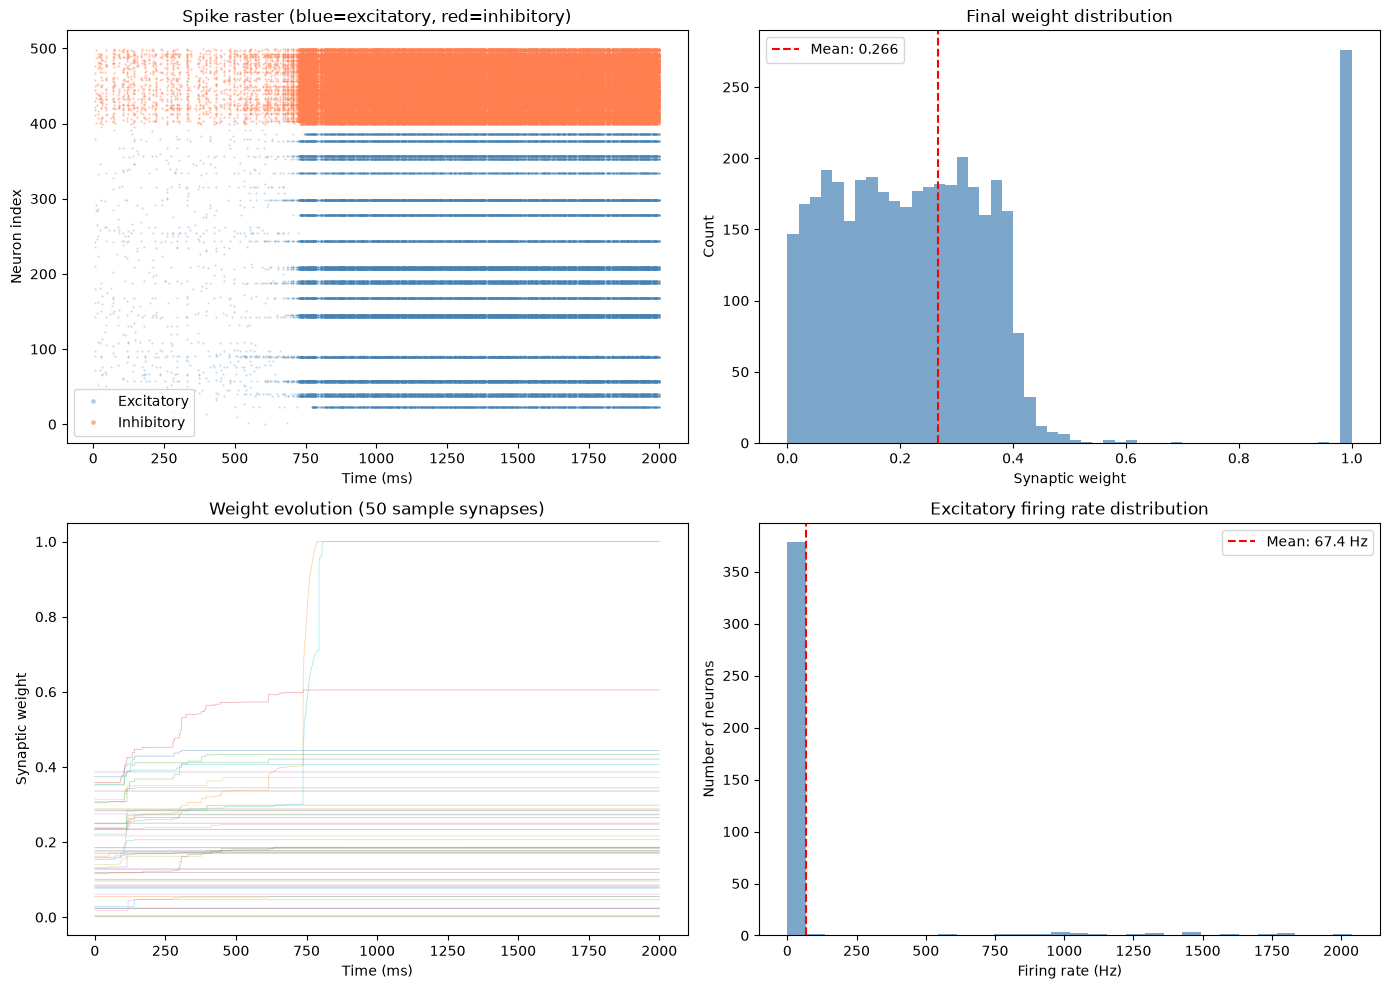


Network statistics:
Excitatory spikes: 53906
Inhibitory spikes: 136059
Mean excitatory firing rate: 67.38 Hz
Mean synaptic weight: 0.2663
Synapses near zero (<0.05): 403
Strong synapses (>0.5): 286


In [10]:
start_scope()

# Network parameters
n_input = 100
n_excit = 400
n_inhib = 100      # new inhibitory population

tau_mem = 20*ms
tau_pre = 20*ms
tau_post = 20*ms

# Separate equations for excitatory and inhibitory neurons
eqs_excit = '''
dv/dt = -v/tau_mem : 1
'''

eqs_inhib = '''
dv/dt = -v/tau_mem : 1
'''

# Create neuron groups
# Change input rate from 10Hz to 15Hz (302.7Hz)
# Change input rate from 15Hz to 12Hz (83.69Hz)
# Keep input rate constant at 12Hz (74.2Hz)
# Keep input rate constant at 12Hz (99.0Hz)
# Keep input rate constant at 12Hz (46.13Hz)
# Keep input rate constant at 12Hz (67.38Hz)
input_layer = PoissonGroup(n_input, rates=12*Hz)

excit_layer = NeuronGroup(n_excit, eqs_excit,
                          threshold='v>0.8',
                          reset='v=0',
                          method='exact')

inhib_layer = NeuronGroup(n_inhib, eqs_inhib,
                          threshold='v>0.8',
                          reset='v=0',
                          method='exact')

# STDP only on excitatory synapses
stdp_eqs = '''
w : 1
dapre/dt = -apre/tau_pre : 1 (event-driven)
dapost/dt = -apost/tau_post : 1 (event-driven)
'''

on_pre_excit = '''
v_post += w
apre += 0.01
w = clip(w + apost, 0, 1)
'''

on_post_excit = '''
apost += 0.01
w = clip(w + apre, 0, 1)
'''

# Input → excitatory (with STDP)
S_input = Synapses(input_layer, excit_layer,
                   stdp_eqs,
                   on_pre=on_pre_excit,
                   on_post=on_post_excit)
S_input.connect(p=0.1)
S_input.w = 'rand() * 0.4'

# Excitatory → inhibitory (fixed weights, no STDP)
S_ei = Synapses(excit_layer, inhib_layer,
                'w : 1', on_pre='v_post += w')
S_ei.connect(p=0.1)
# Change inhibitory weight from 0.3 to 0.2 (302.7Hz)
# Change inhibitory weight from 0.2 to 0.25 (83.69Hz)
# Change inhibitory weight from 0.25 to 0.27 (74.2Hz)
# Change inhibitory weight from 0.27 to 0.3 (99.0Hz)
# Change inhibitory weight from 0.3 to 0.285 (46.13Hz)
# Change inhibitory weight from 0.285 to 0.3 (67.38Hz)
S_ei.w = 0.3

# Inhibitory → excitatory (fixed NEGATIVE weights — this is the brake!)
S_ie = Synapses(inhib_layer, excit_layer,
                'w : 1', on_pre='v_post -= w')
S_ie.connect(p=0.1)
S_ie.w = 0.2

# Excitatory → excitatory recurrent (with STDP)
S_recurrent = Synapses(excit_layer, excit_layer,
                       stdp_eqs,
                       on_pre=on_pre_excit,
                       on_post=on_post_excit)
S_recurrent.connect(p=0.05, condition='i!=j')
S_recurrent.w = 'rand() * 0.2'

# Monitors
spike_mon_e = SpikeMonitor(excit_layer)
spike_mon_i = SpikeMonitor(inhib_layer)
weight_mon = StateMonitor(S_input, 'w', record=range(50))

print("Running balanced network... this may take a minute!")
run(2*second, report='text')

print("Done! Plotting results...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Spike raster - both excitatory and inhibitory
axes[0,0].plot(spike_mon_e.t/ms, spike_mon_e.i,
               '.', color='steelblue', ms=1, alpha=0.3, label='Excitatory')
axes[0,0].plot(spike_mon_i.t/ms, spike_mon_i.i + n_excit,
               '.', color='coral', ms=1, alpha=0.5, label='Inhibitory')
axes[0,0].set_xlabel('Time (ms)')
axes[0,0].set_ylabel('Neuron index')
axes[0,0].set_title('Spike raster (blue=excitatory, red=inhibitory)')
axes[0,0].legend(markerscale=5)

# 2. Weight distribution
axes[0,1].hist(S_input.w, bins=50, color='steelblue', alpha=0.7)
axes[0,1].set_xlabel('Synaptic weight')
axes[0,1].set_ylabel('Count')
axes[0,1].set_title('Final weight distribution')
axes[0,1].axvline(x=np.mean(S_input.w), color='red',
                   linestyle='--', label=f'Mean: {np.mean(S_input.w):.3f}')
axes[0,1].legend()

# 3. Weight evolution
axes[1,0].plot(weight_mon.t/ms, weight_mon.w.T, alpha=0.4, linewidth=0.5)
axes[1,0].set_xlabel('Time (ms)')
axes[1,0].set_ylabel('Synaptic weight')
axes[1,0].set_title('Weight evolution (50 sample synapses)')

# 4. Firing rates
rates_e = np.bincount(spike_mon_e.i, minlength=n_excit) / 2.0
axes[1,1].hist(rates_e, bins=30, color='steelblue', alpha=0.7)
axes[1,1].set_xlabel('Firing rate (Hz)')
axes[1,1].set_ylabel('Number of neurons')
axes[1,1].set_title('Excitatory firing rate distribution')
axes[1,1].axvline(x=np.mean(rates_e), color='red',
                   linestyle='--', label=f'Mean: {np.mean(rates_e):.1f} Hz')
axes[1,1].legend()

plt.tight_layout()
plt.show()

print(f"\nNetwork statistics:")
print(f"Excitatory spikes: {len(spike_mon_e.t)}")
print(f"Inhibitory spikes: {len(spike_mon_i.t)}")
print(f"Mean excitatory firing rate: {np.mean(rates_e):.2f} Hz")
print(f"Mean synaptic weight: {np.mean(S_input.w):.4f}")
print(f"Synapses near zero (<0.05): {np.sum(S_input.w < 0.05)}")
print(f"Strong synapses (>0.5): {np.sum(S_input.w > 0.5)}")

## Network observations & results

### Architecture
A balanced excitatory/inhibitory spiking network with STDP learning.

- 100 input neurons (Poisson, 12 Hz)
- 400 excitatory neurons with recurrent STDP connections
- 100 inhibitory neurons providing feedback suppression

### Parameter tuning: finding E/I balance
The network required careful tuning of both the input firing rate and inhibitory 
synaptic weight `S_ie.w` to maintain biologically realistic firing rates. 
Key observations during tuning:

| Input rate | `S_ie.w` | Mean firing rate | Interpretation |
|------------|----------|-----------------|----------------|
| 15 Hz | 0.20 | ~302.7 Hz | Runaway excitation — brake too weak, input too strong |
| 12 Hz | 0.25 | ~83.69 Hz | Improving but still too active |
| 12 Hz | 0.27 | ~74.2 Hz | Getting closer |
| 12 Hz | 0.30 | ~99.0 Hz | Nonlinear jump upward — hints at multistability |
| 12 Hz | 0.285 | ~46.13 Hz | Sweet spot — biologically realistic |
| 12 Hz | 0.30 | ~67.38 Hz | Different run, same parameters — stochastic variability |

The last two rows highlight a key finding — identical parameters produced 
different firing rates (46 Hz vs 67 Hz) on separate runs, demonstrating 
the network's stochastic nature.

The nonlinear behaviour around `S_ie.w = 0.285–0.30` suggests the network 
may have multiple stable states (**multistability**) — a phenomenon observed 
in real cortical circuits and an active area of computational neuroscience research.

### Stochastic behaviour
The network exhibits **run-to-run variability** due to stochastic initialisation 
— synaptic weights are randomly initialised and input neurons fire according to 
a Poisson process, meaning exact spike timings differ on every run.

**Implication:** Single simulation runs are insufficient to characterise network 
behaviour. In published research, parameters are typically validated by averaging 
across multiple runs and reporting mean ± standard deviation.

### Final results
**Parameters:** `input rate = 12 Hz`, `S_ie.w = 0.3`

| Metric | Value |
|--------|-------|
| Mean excitatory firing rate | 67.38 Hz |
| Excitatory spikes | 53,906 |
| Inhibitory spikes | 136,059 |
| Mean synaptic weight | 0.2663 |
| Synapses pruned (w < 0.05) | 403 |
| Strong synapses (w > 0.5) | 286 |

### Key findings

**E/I balance:** Inhibitory neurons fired more than twice as often as excitatory 
ones (136,059 vs 53,906 spikes) — the brake working continuously to prevent 
runaway excitation and maintain network stability.

**Sparse coding:** Out of thousands of synapses, 403 were effectively eliminated 
and 286 were strongly potentiated. The network selectively retained meaningful 
connections and pruned irrelevant ones — mirroring synaptic pruning observed in 
biological neural development.

**Stochastic variability confirmed:** The same parameters (`S_ie.w = 0.3`) 
produced 99 Hz on one run and 67.38 Hz on another, confirming that individual 
runs should not be over-interpreted. The biologically realistic range of 
46–83 Hz observed across runs validates our parameter choices.
